# Assignment 05 - Population Analysis

## Author: Tihana Gray

This notebook analyses population differences between sexes by age in Ireland.

Libraries:

In [293]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # For plotting graphs

File paths:

In [294]:
file_path = r'C:\\Users\\TihanaGray\\OneDrive - CRS\\Desktop\\ATU\\programming-for-data-analytics\\assignments\\population_for_analysis.csv'

Loading dataset & overview:

In [295]:
df = pd.read_csv(file_path) # Reads the CSV file into a pandas DataFrame.
df.head() # Displays the first few rows of the DataFrame.

,Single Year of Age,Carlow County Council,Cavan County Council,Clare County Council,Cork City Council,Cork County Council,Donegal County Council,Dublin City Council,Dún Laoghaire Rathdown County Council,Fingal County Council,...,Monaghan County Council,Offaly County Council,Roscommon County Council,Sligo County Council,South Dublin County Council,Tipperary County Council,Waterford City & County Council,Westmeath County Council,Wexford County Council,Wicklow County Council
0,0,699.0,1006.0,1377.0,2283.0,4190.0,1797.0,6213.0,2457.0,4009.0,...,868.0,935.0,748.0,743.0,3544.0,1932.0,1340.0,1129.0,1792.0,1710.0
1,1,649.0,1004.0,1360.0,2284.0,4115.0,1881.0,5699.0,2437.0,3894.0,...,821.0,937.0,764.0,766.0,3673.0,1808.0,1266.0,1158.0,1724.0,1682.0
2,2,689.0,1061.0,1473.0,2306.0,4290.0,1971.0,5830.0,2489.0,4308.0,...,870.0,945.0,893.0,764.0,3734.0,1836.0,1329.0,1108.0,1835.0,1796.0
3,3,754.0,1085.0,1468.0,2294.0,4437.0,2074.0,5580.0,2613.0,4384.0,...,900.0,1009.0,859.0,825.0,3856.0,2048.0,1476.0,1148.0,1864.0,1862.0
4,4,745.0,1047.0,1505.0,2243.0,4620.0,2089.0,5624.0,2658.0,4422.0,...,873.0,1007.0,833.0,820.0,3870.0,2072.0,1390.0,1208.0,1941.0,1897.0


### Dataset Overview

The dataset contains population counts by **single year of age** across all **Irish regions**.  
Each column represents a local authority area (region).  
The first column, *Single Year of Age*, provides the age groups used in the analysis.  

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
- https://www.geeksforgeeks.org/pandas/python-pandas-dataframe/

In [296]:
df.info() # Provides a concise summary of the DataFrame.
df.describe() # Generates descriptive statistics of the DataFrame.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Single Year of Age                     101 non-null    int64  
 1   Carlow County Council                  101 non-null    float64
 2   Cavan County Council                   101 non-null    float64
 3   Clare County Council                   101 non-null    float64
 4   Cork City Council                      101 non-null    float64
 5   Cork County Council                    101 non-null    float64
 6   Donegal County Council                 101 non-null    float64
 7   Dublin City Council                    101 non-null    float64
 8   Dún Laoghaire Rathdown County Council  101 non-null    float64
 9   Fingal County Council                  101 non-null    float64
 10  Galway City Council                    101 non-null    float64
 11  Galway

,Single Year of Age,Carlow County Council,Cavan County Council,Clare County Council,Cork City Council,Cork County Council,Donegal County Council,Dublin City Council,Dún Laoghaire Rathdown County Council,Fingal County Council,...,Monaghan County Council,Offaly County Council,Roscommon County Council,Sligo County Council,South Dublin County Council,Tipperary County Council,Waterford City & County Council,Westmeath County Council,Wexford County Council,Wicklow County Council
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,...,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,50.000000,613.544554,808.950495,1266.712871,2217.861386,3565.861386,1654.297030,5868.445545,2315.445545,3272.336634,...,646.415842,823.267327,695.633663,695.029703,2980.940594,1662.326733,1261.019802,952.683168,1622.960396,1543.079208
std,29.300171,306.958516,406.352344,608.585760,1121.260568,1819.709059,777.550083,3427.079989,1038.389777,1920.958809,...,319.105916,407.154636,322.614963,316.910222,1608.771816,777.912104,599.663956,474.335977,778.904422,792.008203
min,0.000000,3.000000,6.000000,14.000000,23.000000,25.000000,15.000000,64.000000,32.000000,21.000000,...,5.000000,4.000000,7.000000,10.000000,17.000000,10.000000,17.000000,6.000000,16.000000,8.000000
25%,25.000000,412.000000,582.000000,1058.000000,1518.000000,2620.000000,1407.000000,3409.000000,1796.000000,1732.000000,...,492.000000,606.000000,568.000000,583.000000,1803.000000,1301.000000,1000.000000,634.000000,1280.000000,1114.000000
50%,50.000000,713.000000,915.000000,1431.000000,2525.000000,3841.000000,1826.000000,5912.000000,2775.000000,3660.000000,...,732.000000,935.000000,794.000000,799.000000,3544.000000,1834.000000,1462.000000,1103.000000,1817.000000,1702.000000
75%,75.000000,835.000000,1143.000000,1758.000000,3103.000000,5072.000000,2285.000000,7914.000000,3054.000000,4863.000000,...,894.000000,1161.000000,957.000000,935.000000,4193.000000,2253.000000,1725.000000,1329.000000,2258.000000,2197.000000
max,100.000000,1045.000000,1343.000000,2029.000000,3677.000000,6116.000000,2632.000000,12366.000000,3739.000000,6350.000000,...,1072.000000,1397.000000,1100.000000,1089.000000,5428.000000,2581.000000,2094.000000,1561.000000,2709.000000,2744.000000


### Checking the Data

The `.info()` method confirms the dataset structure —  all region columns should be numeric (population counts), and  `'Single Year of Age'` should contain integer age values.  

`.describe()` provides a quick statistical summary of numeric columns to check for missing values, outliers, or unusual ranges. 

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

## Part 1: Write a Jupyter notebook that analyses the differences between the regions by age in Ireland.

This section calculates the 'weighted mean age' for each region, using population counts as weights.  

Lists to store results:

In [297]:
region_list = []
mean_list = [] # Lists to store results.

In [298]:
for region in df.columns[1:]: # Looping over all columns except the first (which is 'Single Year of Age')
    mean_age = np.average(df['Single Year of Age'], weights=df[region]) # Calculates the weighted average age for the region.
    region_list.append(region)
    mean_list.append(mean_age)


📚 References: 
- https://numpy.org/doc/stable/reference/generated/numpy.average.html
- https://docs.python.org/3/tutorial/datastructures.html#more-on-lists
- https://www.geeksforgeeks.org/python/how-to-calculate-weighted-average-in-pandas/
- https://www.geeksforgeeks.org/pandas/different-ways-to-iterate-over-rows-in-pandas-dataframe/

In [299]:
weighted_mean_df = pd.DataFrame({'Region': region_list,'Weighted_Mean_Age': mean_list}) # Creates a new DataFrame with the results.

print("Weighted Mean Age by Region:\n")
weighted_mean_df

Weighted Mean Age by Region:



,Region,Weighted_Mean_Age
0,Carlow County Council,38.274997
1,Cavan County Council,38.033511
2,Clare County Council,39.582165
3,Cork City Council,38.575414
4,Cork County Council,38.600991
5,Donegal County Council,39.649075
6,Dublin City Council,38.111410
7,Dún Laoghaire Rathdown County Council,39.458445
8,Fingal County Council,35.696139
9,Galway City Council,36.871372


This shows the average age for each region, adjusted for its population distribution.

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
- https://pandas.pydata.org/docs/dev/reference/api/pandas.DataFrame.ewm.html
- https://www.geeksforgeeks.org/python/python-pandas-dataframe-mean/
- https://www.geeksforgeeks.org/python/python-new-line-add-print-a-new-line/
- https://www.geeksforgeeks.org/python/how-to-calculate-weighted-average-in-pandas/
- https://stackoverflow.com/questions/35368581/pandas-weighted-mean

In [300]:
region_columns = df.columns[1:] # All columns except the first one.
df['Max_Region_Pop'] = df[region_columns].max(axis=1) # Finds the maximum population across regions for each age.
df['Min_Region_Pop'] = df[region_columns].min(axis=1) # Finds the minimum population across regions for each age.
df['Regional_Difference'] = df['Max_Region_Pop'] - df['Min_Region_Pop'] # Calculates the difference.

print("Population difference between regions by age (first five rows):")
df[['Single Year of Age', 'Max_Region_Pop', 'Min_Region_Pop', 'Regional_Difference']].head()

Population difference between regions by age (first five rows):


,Single Year of Age,Max_Region_Pop,Min_Region_Pop,Regional_Difference
0,0,57796.0,404.0,57392.0
1,1,56420.0,406.0,56014.0
2,2,59210.0,453.0,58757.0
3,3,60484.0,432.0,60052.0
4,4,61505.0,450.0,61055.0


- `max(axis=1)` and `min(axis=1)` compute values horizontally across regions for each row (age).  
- Subtracting these gives the population spread between the most and least populated regions.  
- This quantifies how unevenly distributed populations are across Ireland at each age level.

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.max.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.min.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
- https://docs.python.org/3/library/functions.html#print
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html

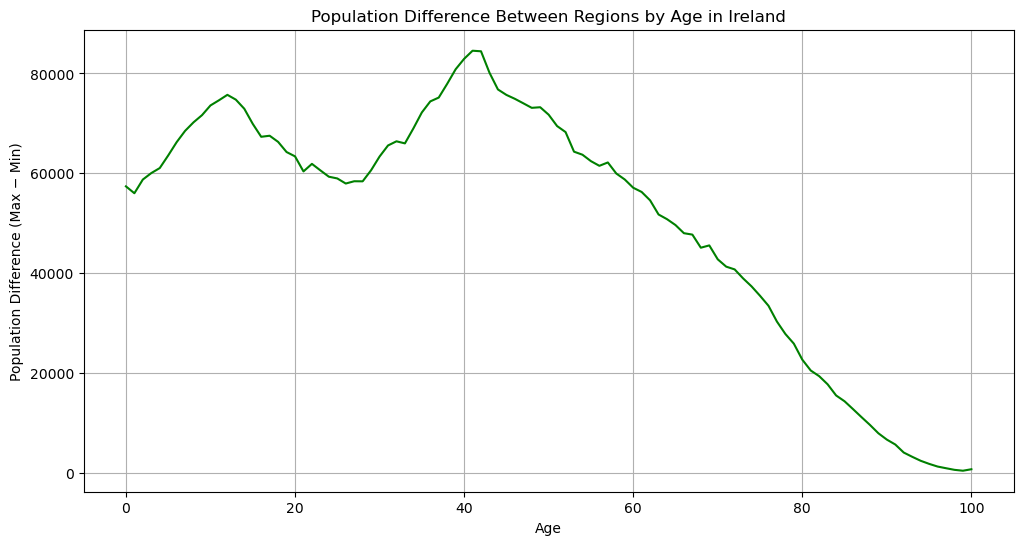

In [301]:
plt.figure(figsize=(12, 6)) # Sets the figure size.
plt.plot(df['Single Year of Age'], df['Regional_Difference'], color='green') # Plots the age vs. population difference.
plt.title('Population Difference Between Regions by Age in Ireland') # Sets the title of the plot.
plt.xlabel('Age') # Sets the x-axis label.
plt.ylabel('Population Difference (Max − Min)') # Sets the y-axis label.
plt.grid(True) # Adds a grid to the plot.
plt.show() # Displays the plot.

This chart shows the range in population size among regions for each age. A taller peak means a greater population disparity between Irish councils by age.

📚 References: 
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
- https://www.geeksforgeeks.org/python/matplotlib-pyplot-xlabels-in-python/
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.grid.html

## Part 2: Write that code that would group the people within 5 years of that age together, into one age group and calculate the population difference between the regions in that age group.

In [302]:
target_age = 35 # Example target age

age_group = df[(df['Single Year of Age'] >= target_age - 5) & (df['Single Year of Age'] <= target_age + 5)] # Filters the DataFrame for the age group.

region_sums = age_group.iloc[:, 1:].sum() # Sums the populations for each region in the age group.

print(f"Total population for ages {target_age-5}–{target_age+5} (by region):") # Displays the total populations.
region_sums


Total population for ages 30–40 (by region):


Carlow County Council                      9225.0
Cavan County Council                      11926.0
Clare County Council                      16981.0
Cork City Council                         38562.0
Cork County Council                       50251.0
Donegal County Council                    22321.0
Dublin City Council                      120698.0
Dún Laoghaire Rathdown County Council     35524.0
Fingal County Council                     55242.0
Galway City Council                       14806.0
Galway County Council                     26325.0
Ireland                                  798536.0
Kerry County Council                      21082.0
Kildare County Council                    39273.0
Kilkenny County Council                   14531.0
Laois County Council                      14275.0
Leitrim County Council                     4703.0
Limerick City & County Council            31616.0
Longford County Council                    6901.0
Louth County Council                      20755.0


This part stores the target age as an integer and filters rows to include +/- 5 years with Boolean indexing. Then it adds numeric values and formats the output.

📚 References: 
- https://docs.python.org/3/reference/simple_stmts.html#assignment-statements
- https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html
- https://pandas.pydata.org/docs/user_guide/indexing.html
- https://www.geeksforgeeks.org/pandas/boolean-indexing-in-pandas/
- https://docs.python.org/3/tutorial/inputoutput.html#formatted-string-literals
- https://docs.python.org/3/library/functions.html#print


In [303]:
max_region = region_sums.idxmax() # Identifies the region with the maximum population.
min_region = region_sums.idxmin() # Identifies the region with the minimum population.
max_value = region_sums.max() # Maximum population value.
min_value = region_sums.min() # Minimum population value.
population_difference = max_value - min_value # Calculates the population difference.

print(f"\nHighest regional population in ages {target_age-5}–{target_age+5}: {max_region} ({max_value:,})") # Displays the region with the highest population.
print(f"Lowest regional population in ages {target_age-5}–{target_age+5}: {min_region} ({min_value:,})") # Displays the region with the lowest population.
print(f"Population difference between highest and lowest regions: {population_difference:,}") # Displays the population difference.
#  print() with f-strings for formatted output with comma separators for readability.


Highest regional population in ages 30–40: Ireland (798,536.0)
Lowest regional population in ages 30–40: Leitrim County Council (4,703.0)
Population difference between highest and lowest regions: 793,833.0


- The region with the highest and lowest population totals is identified.  
- Their difference represents the population gap between the most and least populated regions within that age group.

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.Series.idxmax.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.idxmin.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.max.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.min.html
- https://docs.python.org/3/reference/expressions.html#arithmetic-conversions
- https://docs.python.org/3/tutorial/inputoutput.html#formatted-string-literals

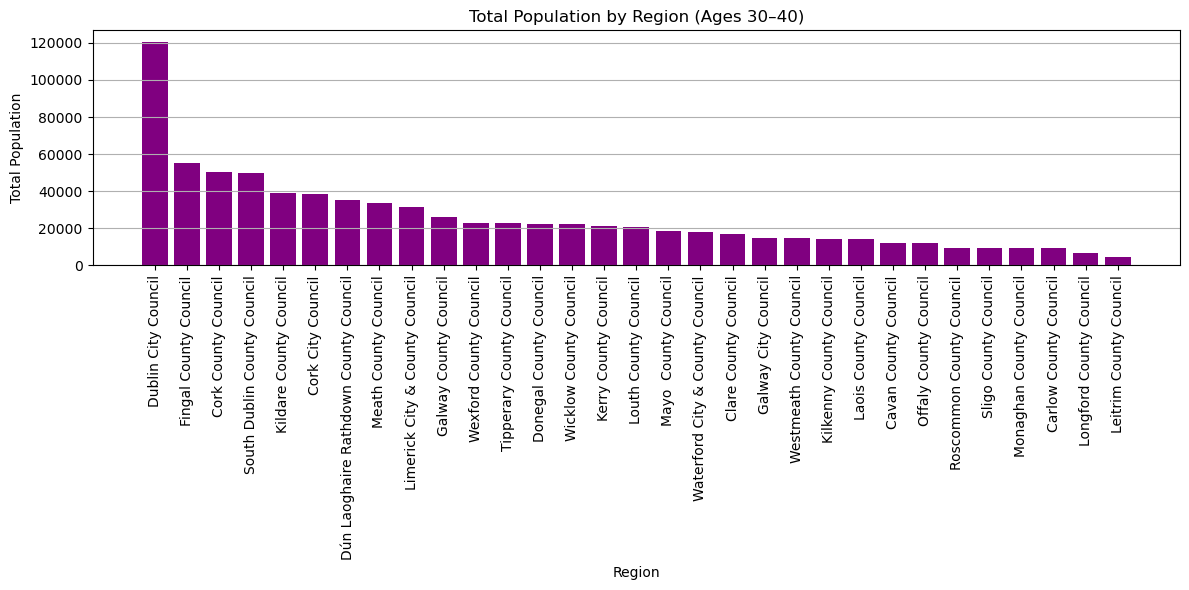

In [304]:
region_sums.index = region_sums.index.str.strip() # Strips any leading/trailing whitespace from region names.
region_sums_filtered = region_sums.drop(labels=['Ireland', 'Max_Region_Pop', 'Min_Region_Pop', 'Regional_Difference'], errors='ignore') # Removes the 'Ireland' total if present.
region_sums_filtered = region_sums_filtered.sort_values(ascending=False) # Sorts the series in descending order.


plt.figure(figsize=(12,6)) # Sets the figure size.
plt.bar(region_sums_filtered.index, region_sums_filtered.values, color='purple') # Creates a bar chart of the regional populations.
plt.xticks(rotation=90) # Rotates x-axis labels for better readability.
plt.title(f'Total Population by Region (Ages {target_age-5}–{target_age+5})') # Sets the title of the plot.
plt.xlabel('Region') # Sets the x-axis label.
plt.ylabel('Total Population') # Sets the y-axis label.     
plt.grid(axis='y') # Adds a grid to the y-axis.
plt.tight_layout() # Adjusts layout to prevent clipping of tick-labels.
plt.show() # Displays the plot.

This part is visualising council totals in the set age range.

📚 References: 
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.drop.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html

## Part 3: Code that would work out which region in Ireland has the biggest population difference between the regions in that age group.

In [305]:
region_sums.index = region_sums.index.str.strip() # Strips any leading/trailing whitespace from region names.
region_sums_filtered = region_sums.drop(labels=['Ireland', 'Max_Region_Pop', 'Min_Region_Pop', 'Regional_Difference'],errors='ignore') # Removes the unnecessary labels.

mean_population = region_sums_filtered.mean() # Calculates the mean population across regions.
regional_differences = (region_sums_filtered - mean_population).abs() # Calculates the absolute differences from the mean.
max_diff_region = regional_differences.idxmax() # Identifies the region with the maximum difference from the mean.
max_diff_value = regional_differences.max() # Maximum difference value.

print("Region with the largest population difference (from the mean) in the target age group:")  # Displays the result.
print(f"{max_diff_region}: difference of {max_diff_value:,.0f} people from the regional average.") # Formatted output with comma separators for readability.

Region with the largest population difference (from the mean) in the target age group:
Dublin City Council: difference of 94,939 people from the regional average.


- “Ireland” (national total) and any calculated fields are excluded.  
- The mean population of all true regions is shown.  
- Each region’s total population is compared to that mean.  
- The region with the largest absolute difference represents the area most unlike the average in that age group.  

📚 References: 
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.drop.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.abs.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.idxmax.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.max.html
- https://docs.python.org/3/library/functions.html#print
- https://docs.python.org/3/tutorial/inputoutput.html#formatted-string-literals

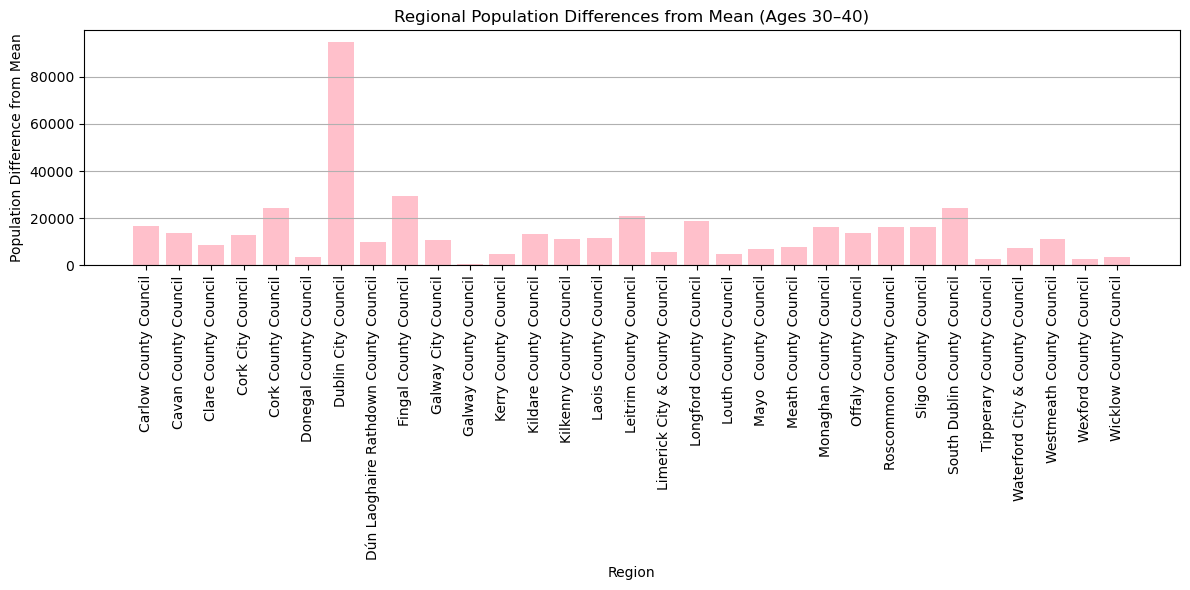

In [306]:
plt.figure(figsize=(12,6)) # Sets the figure size. 
plt.bar(regional_differences.index, regional_differences.values, color='pink') # Creates a bar chart of the regional population differences.
plt.xticks(rotation=90) # Rotates x-axis labels for better readability.
plt.title(f'Regional Population Differences from Mean (Ages {target_age-5}–{target_age+5})') # Sets the title of the plot.
plt.xlabel('Region') # Sets the x-axis label.
plt.ylabel('Population Difference from Mean') # Sets the y-axis label.
plt.grid(axis='y') # Adds a grid to the y-axis.
plt.tight_layout() # Adjusts layout to prevent clipping of tick-labels.
plt.show() # Displays the plot.


Visualisation of reginal population difference.

📚 References:
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.grid.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

## End